# Gradient Descent

*How machines "learn" by taking small steps downhill*

In this lesson we will build up the single most important idea behind training
neural networks: **gradient descent**. By the end you will be able to:

1. Explain what a *loss function* is and why we want to make it small.
2. Describe gradient descent as "walking downhill" on a curve.
3. Write Python code that finds the lowest point of a function all by itself.
4. See how the **learning rate** controls whether learning works or blows up.
5. Use gradient descent to fit a straight line to real data — a tiny neural network.

## 1. The big idea: find the bottom of the valley

Imagine you are standing somewhere on a hillside in thick fog. You cannot see the
bottom of the valley, but you *can* feel which way the ground slopes under your
feet. A sensible plan:

> Take a small step in the **downhill** direction. Repeat until the ground is flat.

That is literally the whole algorithm. The "hill" is a function we want to
minimize, "which way is downhill" is given by the **slope** (the derivative), and
"a small step" is controlled by a number we call the **learning rate**.

Why do we care? When a neural network learns, we measure *how wrong* its
predictions are with a number called the **loss**. Training the network means
adjusting its numbers (weights) to make the loss as small as possible. The
landscape of "loss vs. weights" is our foggy hill.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (7, 4.5)
plt.rcParams["axes.grid"] = True

## 2. Our practice hill: $y = x^2$

The function $y = x^2$ is a perfect first example:

- It is a smooth U-shaped curve (a *parabola*).
- Its lowest point is obviously at $x = 0$, where $y = 0$.
- We can therefore *check* whether our algorithm finds the right answer.

Let's plot it.

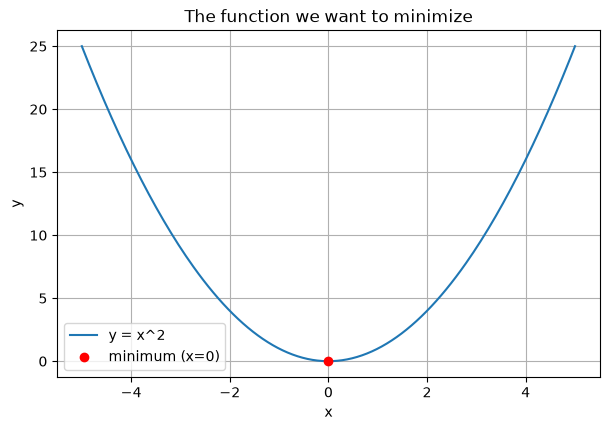

In [ ]:
def f(x):
    return x**2


x = np.linspace(-5, 5, 200)

plt.plot(x, f(x), label="y = x^2")
plt.scatter([0], [0], color="red", zorder=5, label="minimum (x=0)")
plt.xlabel("x")
plt.ylabel("y")
plt.title("The function we want to minimize")
plt.legend()
plt.show()

## 3. Which way is downhill? The slope

At any point on the curve, the **slope** tells us how steep the hill is and in
which direction it rises.

- If the slope is **positive**, the curve goes *up* as we move right, so downhill
  is to the **left**.
- If the slope is **negative**, downhill is to the **right**.
- If the slope is **zero**, we are on flat ground — possibly the bottom!

For $y = x^2$, calculus tells us the slope at a point $x$ is:

$$\frac{dy}{dx} = 2x$$

This "slope function" is called the **gradient** (in 1-D it's just the
derivative). You do not need to have studied calculus to continue — think of
`gradient(x)` as a machine that reports the steepness at position `x`.

In [ ]:
def gradient(x):
    "Slope of y = x^2 at position x."
    return 2 * x


for point in [-3, -1, 0, 2, 4]:
    print(f"at x = {point:2d}, height y = {f(point):2d}, slope = {gradient(point):3d}")

at x = -3, height y =  9, slope =  -6
at x = -1, height y =  1, slope =  -2
at x =  0, height y =  0, slope =   0
at x =  2, height y =  4, slope =   4
at x =  4, height y = 16, slope =   8


Notice:

- At `x = -3` the slope is `-6` (steep, pointing down-right) → we should move **right**.
- At `x = 2` the slope is `+4` → we should move **left**.
- At `x = 0` the slope is `0` → we have arrived.

The pattern: **move in the direction opposite to the slope.**

## 4. One step of gradient descent, by hand

The update rule is:

$$x_{\text{new}} = x_{\text{old}} - (\text{learning rate}) \times \text{slope at } x_{\text{old}}$$

The minus sign is what makes us go *downhill* instead of uphill.

Let's start at `x = 4` and take a single step with a learning rate of `0.1`.

In [4]:
learning_rate = 0.1
x_old = 4.0

slope = gradient(x_old)
x_new = x_old - learning_rate * slope

print(f"start:  x = {x_old},  y = {f(x_old)}")
print(f"slope at start: {slope}")
print(f"step:   x_new = {x_old} - {learning_rate} * {slope} = {x_new}")
print(f"after:  x = {x_new},  y = {f(x_new):.3f}")
print()
print("We moved closer to 0 and the height went down. It works!")

start:  x = 4.0,  y = 16.0
slope at start: 8.0
step:   x_new = 4.0 - 0.1 * 8.0 = 3.2
after:  x = 3.2,  y = 10.240

We moved closer to 0 and the height went down. It works!


## 5. Many steps: the full algorithm

One step helped a little. Let's just repeat it many times with a loop and record
where we go.

In [ ]:
def gradient_descent(start, learning_rate, n_steps):
    "Return the list of x positions visited by gradient descent."
    x = start
    history = [x]
    for _ in range(n_steps):
        x = x - learning_rate * gradient(x)
        history.append(x)
    return history


path = gradient_descent(start=4.0, learning_rate=0.1, n_steps=30)

for i, xi in enumerate(path):
    print(f"step {i:2d}:  x = {xi:+.5f}   y = {f(xi):.5f}")

step  0:  x = +4.00000   y = 16.00000
step  1:  x = +3.20000   y = 10.24000
step  2:  x = +2.56000   y = 6.55360
step  3:  x = +2.04800   y = 4.19430
step  4:  x = +1.63840   y = 2.68435
step  5:  x = +1.31072   y = 1.71799
step  6:  x = +1.04858   y = 1.09951
step  7:  x = +0.83886   y = 0.70369
step  8:  x = +0.67109   y = 0.45036
step  9:  x = +0.53687   y = 0.28823
step 10:  x = +0.42950   y = 0.18447
step 11:  x = +0.34360   y = 0.11806
step 12:  x = +0.27488   y = 0.07556
step 13:  x = +0.21990   y = 0.04836
step 14:  x = +0.17592   y = 0.03095
step 15:  x = +0.14074   y = 0.01981
step 16:  x = +0.11259   y = 0.01268
step 17:  x = +0.09007   y = 0.00811
step 18:  x = +0.07206   y = 0.00519
step 19:  x = +0.05765   y = 0.00332
step 20:  x = +0.04612   y = 0.00213
step 21:  x = +0.03689   y = 0.00136
step 22:  x = +0.02951   y = 0.00087
step 23:  x = +0.02361   y = 0.00056
step 24:  x = +0.01889   y = 0.00036
step 25:  x = +0.01511   y = 0.00023
step 26:  x = +0.01209   y = 0.00015

The position marches steadily toward `0`, and the height shrinks toward `0`.
The steps get **smaller and smaller** on their own — because near the bottom the
hill is nearly flat, so the slope (and therefore the step) is tiny. Gradient
descent naturally slows down as it closes in.

## 6. Watch it roll downhill

A picture makes the "walking downhill" idea obvious. Each dot is one step.

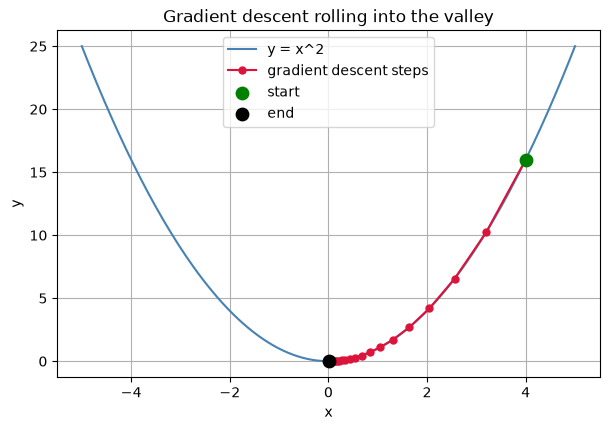

Ended at x = 0.00495 (true answer is 0)


In [ ]:
path = gradient_descent(start=4.0, learning_rate=0.1, n_steps=30)
path = np.array(path)

x = np.linspace(-5, 5, 200)
plt.plot(x, f(x), color="steelblue", label="y = x^2")
plt.plot(path, f(path), "o-", color="crimson", markersize=5, label="gradient descent steps")
plt.scatter([path[0]], [f(path[0])], color="green", zorder=6, s=80, label="start")
plt.scatter([path[-1]], [f(path[-1])], color="black", zorder=6, s=80, label="end")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Gradient descent rolling into the valley")
plt.legend()
plt.show()

print(f"Ended at x = {path[-1]:.5f} (true answer is 0)")

We can also plot the **loss curve**: the height $y$ after each step. This is the
single most common plot you will see while training neural networks — everyone
stares at it hoping it goes down.

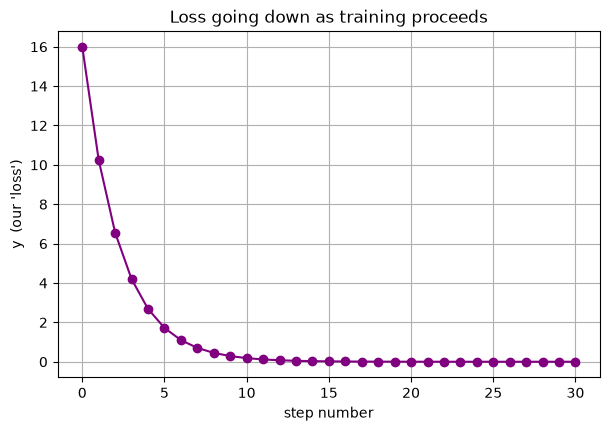

In [7]:
plt.plot(f(path), "o-", color="purple")
plt.xlabel("step number")
plt.ylabel("y  (our 'loss')")
plt.title("Loss going down as training proceeds")
plt.show()

## 7. The learning rate matters — a lot

The learning rate is the size of our steps. It is the most important dial to get
right. Let's try several values from the same starting point.

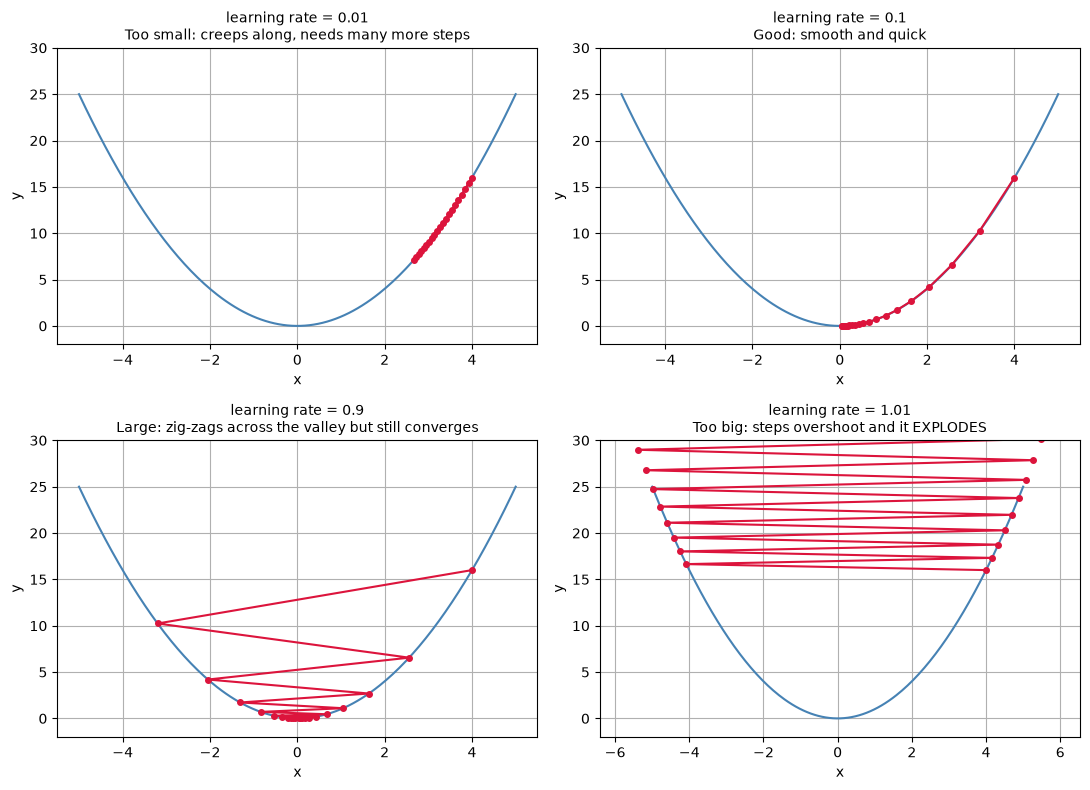

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
x = np.linspace(-5, 5, 200)

settings = [
    (0.01, "Too small: creeps along, needs many more steps"),
    (0.1, "Good: smooth and quick"),
    (0.9, "Large: zig-zags across the valley but still converges"),
    (1.01, "Too big: steps overshoot and it EXPLODES"),
]

for ax, (lr, title) in zip(axes.flat, settings):
    path = np.array(gradient_descent(start=4.0, learning_rate=lr, n_steps=20))
    ax.plot(x, f(x), color="steelblue")
    ax.plot(path, f(path), "o-", color="crimson", markersize=4)
    ax.set_title(f"learning rate = {lr}\n{title}", fontsize=10)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    # keep the explosive case readable
    ax.set_ylim(-2, 30)

plt.tight_layout()
plt.show()

In [9]:
# The numbers behind the "explosion"
bad = gradient_descent(start=4.0, learning_rate=1.01, n_steps=10)
for i, xi in enumerate(bad):
    print(f"step {i:2d}:  x = {xi:+.3f}   y = {f(xi):,.1f}")
print("\nEach step lands further from 0 instead of closer. Learning has failed.")

step  0:  x = +4.000   y = 16.0
step  1:  x = -4.080   y = 16.6
step  2:  x = +4.162   y = 17.3
step  3:  x = -4.245   y = 18.0
step  4:  x = +4.330   y = 18.7
step  5:  x = -4.416   y = 19.5
step  6:  x = +4.505   y = 20.3
step  7:  x = -4.595   y = 21.1
step  8:  x = +4.687   y = 22.0
step  9:  x = -4.780   y = 22.9
step 10:  x = +4.876   y = 23.8

Each step lands further from 0 instead of closer. Learning has failed.


**Takeaways about the learning rate:**

| Learning rate | What happens |
|---|---|
| Way too small | Learns *eventually*, but wastes huge amounts of time |
| Just right | Loss drops quickly and smoothly to the minimum |
| A bit too big | Bounces around, overshooting back and forth, but still gets there |
| Too big | Each step overshoots more than the last — the loss blows up to infinity |

Choosing the learning rate is part of the *art* of training neural networks.

## 8. A trickier hill: local minimums

Real loss landscapes are bumpy. Gradient descent only feels the ground right
under its feet, so it walks into the **nearest** valley — which might not be the
deepest one. Consider:

$$y = x^4 - 3x^3 + 2$$

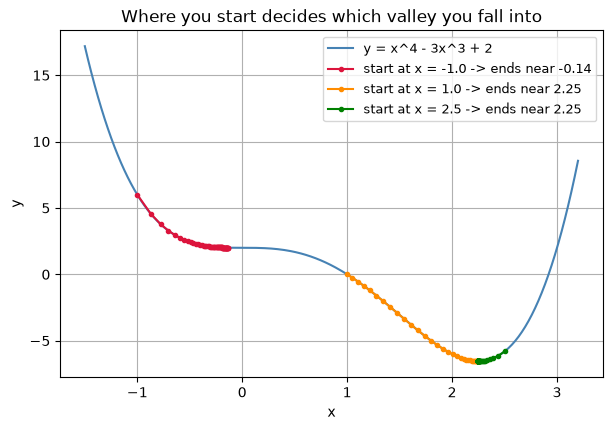

In [ ]:
def g(x):
    return x**4 - 3 * x**3 + 2


def g_gradient(x):
    return 4 * x**3 - 9 * x**2


def descend(grad_fn, start, lr, n_steps):
    x = start
    hist = [x]
    for _ in range(n_steps):
        x = x - lr * grad_fn(x)
        hist.append(x)
    return np.array(hist)


x = np.linspace(-1.5, 3.2, 300)
plt.plot(x, g(x), color="steelblue", label="y = x^4 - 3x^3 + 2")

for start, color in [(-1.0, "crimson"), (1.0, "darkorange"), (2.5, "green")]:
    path = descend(g_gradient, start=start, lr=0.01, n_steps=60)
    plt.plot(path, g(path), "o-", color=color, markersize=3, label=f"start at x = {start} -> ends near {path[-1]:.2f}")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Where you start decides which valley you fall into")
plt.legend(fontsize=9)
plt.show()

Starting on the left, gradient descent gets stuck in the shallow dip near
`x = 0` (a **local minimum**). Starting further right, it finds the true deepest
point (the **global minimum**) near `x = 2.25`.

In practice, big neural networks have millions of dimensions, and it turns out
that "good enough" valleys are usually easy to find — but this is why we often
train several times with different random starting points.

## 9. The real payoff: fitting a line to data

Here is where it connects to machine learning. Suppose we measured some data and
want the best straight line $\hat{y} = w x + b$ through it. "Best" means the line
that makes the smallest total error.

We measure error with the **mean squared error (MSE)** loss:

$$L(w, b) = \frac{1}{n}\sum_{i=1}^{n} \big(\underbrace{w x_i + b}_{\text{prediction}} - y_i\big)^2$$

Now the "hill" is $L$ and the things we adjust are $w$ and $b$. We need the slope
of the loss with respect to *each* of them:

$$\frac{\partial L}{\partial w} = \frac{2}{n}\sum (w x_i + b - y_i)\, x_i
\qquad
\frac{\partial L}{\partial b} = \frac{2}{n}\sum (w x_i + b - y_i)$$

Same algorithm as before, just two knobs instead of one.

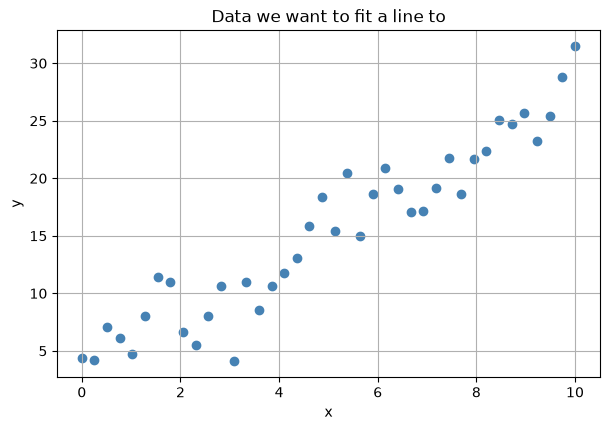

In [11]:
# Some (x, y) data that roughly follows a line, with noise
rng = np.random.default_rng(0)
x_data = np.linspace(0, 10, 40)
y_data = 2.3 * x_data + 4.0 + rng.normal(0, 3, size=x_data.size)

plt.scatter(x_data, y_data, color="steelblue")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Data we want to fit a line to")
plt.show()

In [ ]:
def mse_loss(w, b):
    predictions = w * x_data + b
    return np.mean((predictions - y_data) ** 2)


def loss_gradients(w, b):
    predictions = w * x_data + b
    error = predictions - y_data
    dw = 2 * np.mean(error * x_data)
    db = 2 * np.mean(error)
    return dw, db


# Start with a bad guess: a flat line at zero
w, b = 0.0, 0.0
learning_rate = 0.01
loss_history = []

for step in range(2000):
    dw, db = loss_gradients(w, b)
    w = w - learning_rate * dw
    b = b - learning_rate * db
    loss_history.append(mse_loss(w, b))

print(f"Learned line:  y = {w:.3f} x + {b:.3f}")
print(f"(the data was built from  y = 2.3 x + 4.0  plus noise)")
print(f"Final loss: {loss_history[-1]:.3f}")

Learned line:  y = 2.393 x + 3.355
(the data was built from  y = 2.3 x + 4.0  plus noise)
Final loss: 5.501


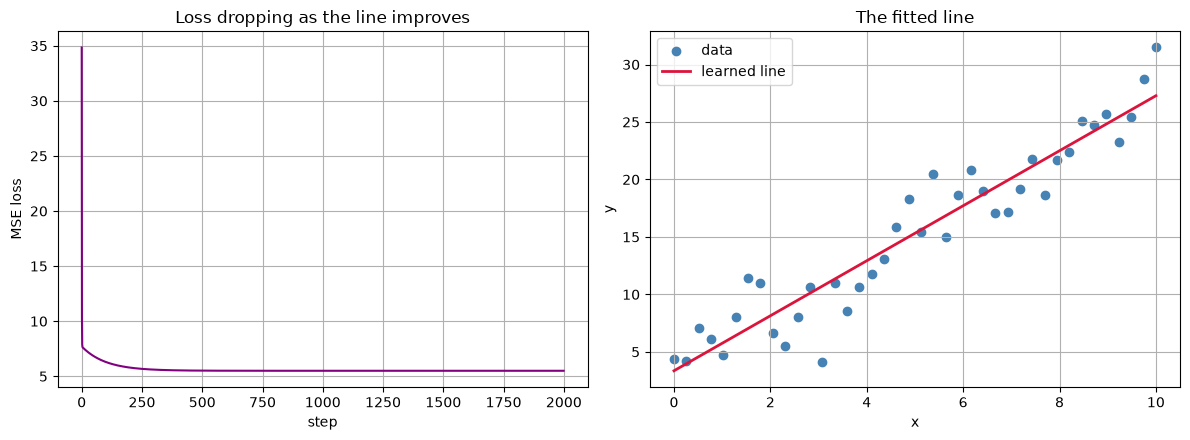

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.plot(loss_history, color="purple")
ax1.set_xlabel("step")
ax1.set_ylabel("MSE loss")
ax1.set_title("Loss dropping as the line improves")

ax2.scatter(x_data, y_data, color="steelblue", label="data")
xs = np.array([x_data.min(), x_data.max()])
ax2.plot(xs, w * xs + b, color="crimson", linewidth=2, label="learned line")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_title("The fitted line")
ax2.legend()

plt.tight_layout()
plt.show()

That is a complete, if tiny, neural network: one input, one output, two
parameters (`w` and `b`), trained by gradient descent. A deep network is the same
loop — measure the loss, compute the slope with respect to every weight, nudge
every weight a little downhill — just with millions of weights and a cleverer way
of computing all those slopes at once (called **backpropagation**, our next
lesson).

## 10. Recap

- A **loss function** measures how wrong a model is. Learning = making it small.
- **Gradient descent**: repeatedly step in the direction opposite the slope.
  $$x \leftarrow x - \text{lr} \times \text{gradient}$$
- The **learning rate** sets the step size: too small is slow, too big explodes.
- Gradient descent finds the *nearest* valley, not necessarily the deepest one.
- Fitting a line to data is gradient descent on the MSE loss over two parameters
  — the seed of how every neural network is trained.

## 11. Your turn — exercises

1. **Different start.** Change the starting point in `gradient_descent` to `-4`.
   Does it still reach `0`? Plot the path.
2. **Find the sweet spot.** For $y = x^2$, roughly what is the *largest* learning
   rate that still converges? Try values between `0.9` and `1.0`. What happens
   exactly at `1.0`?
3. **New function.** Minimize $y = (x - 3)^2 + 5$. Its gradient is $2(x - 3)$.
   Where is the minimum, and what `y` value does your code reach?
4. **Step count.** In the line-fitting example, reduce the loop from `2000` steps
   to `100`. How good is the fit? Now raise the learning rate to `0.02` with
   `100` steps — better or worse?
5. **Harder:** add a `learning_rate` schedule that halves the rate every 500
   steps in the line-fitting loop. Does the final loss improve?

In [14]:
# Space for your experiments